# CNN Using The MNIST Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

import time

In [ ]:
# Creating a Model with Two convolutional Layers and Two Fully Connected Layers
class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self):

        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.out = nn.Linear(84,10)
        
        
    def forward(self, X):
        
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)

        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)

        X = X.view(-1, 16*5*5)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.out(X)

        return F.log_softmax(X, dim =1)

In [3]:
transform = transforms.ToTensor()

In [ ]:
# Importing data from datatsets
training_data = datasets.MNIST(root = "./CNN_data", train = True, transform=transform, download = True)
testing_data = datasets.MNIST(root = "./CNN_data", train = False, transform=transform, download = True)

In [5]:
training_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./CNN_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
testing_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./CNN_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [ ]:
# Creating training_loader testing_loader objects with batch size of 10
training_loader = DataLoader(training_data, batch_size = 10, shuffle = True)
testing_loader = DataLoader(testing_data, batch_size = 10, shuffle = False)

In [22]:
type(training_loader)

torch.utils.data.dataloader.DataLoader

In [ ]:
# Creating a ConvolutionNeuralNetwork instance
torch.manual_seed(41)
cnn_model_1 = ConvolutionalNeuralNetwork()
cnn_model_1

ConvolutionalNeuralNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (out): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model_1.parameters(), lr= 0.0009)

In [10]:
start_time = time.time()

epoch = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epoch):
    trn_correct = 0
    tst_correct = 0
    trn_loss = 0                                                   
    tst_loss = 0                                                   

    for batch, (X_train, y_train) in enumerate(training_loader):
        y_pred = cnn_model_1(X_train)
        loss = loss_function(y_pred, y_train)

        predicted = torch.max(y_pred.data, 1)[1]
        trn_correct += (predicted == y_train).sum()
        trn_loss += loss.item()                                     

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 == 0:
            print(f"Epoch: {i}\t Batch: {batch}\t Loss: {loss.item():.4f}")

    train_losses.append(trn_loss / len(training_loader))           
    train_correct.append(trn_correct)

    with torch.no_grad():                                          
        for batch, (X_test, y_test) in enumerate(testing_loader):
            y_val = cnn_model_1(X_test)
            predicted = torch.max(y_val.data, 1)[1]
            tst_correct += (predicted == y_test).sum()
            tst_loss += loss_function(y_val, y_test).item()        

    test_losses.append(tst_loss / len(testing_loader))            
    test_correct.append(tst_correct)

current_time = time.time()
print(f"Time Elapsed: {((current_time - start_time)/60):.2f} min")

Epoch: 0	 Batch: 0	 Loss: 2.2909
Epoch: 0	 Batch: 500	 Loss: 0.1115
Epoch: 0	 Batch: 1000	 Loss: 0.4100
Epoch: 0	 Batch: 1500	 Loss: 0.0265
Epoch: 0	 Batch: 2000	 Loss: 0.0770
Epoch: 0	 Batch: 2500	 Loss: 0.0106
Epoch: 0	 Batch: 3000	 Loss: 0.0509
Epoch: 0	 Batch: 3500	 Loss: 0.0040
Epoch: 0	 Batch: 4000	 Loss: 0.0050
Epoch: 0	 Batch: 4500	 Loss: 0.1724
Epoch: 0	 Batch: 5000	 Loss: 0.0452
Epoch: 0	 Batch: 5500	 Loss: 0.2009
Epoch: 1	 Batch: 0	 Loss: 0.0144
Epoch: 1	 Batch: 500	 Loss: 0.1211
Epoch: 1	 Batch: 1000	 Loss: 0.0655
Epoch: 1	 Batch: 1500	 Loss: 0.0017
Epoch: 1	 Batch: 2000	 Loss: 0.1812
Epoch: 1	 Batch: 2500	 Loss: 0.0030
Epoch: 1	 Batch: 3000	 Loss: 0.0020
Epoch: 1	 Batch: 3500	 Loss: 0.0038
Epoch: 1	 Batch: 4000	 Loss: 0.5226
Epoch: 1	 Batch: 4500	 Loss: 0.1368
Epoch: 1	 Batch: 5000	 Loss: 0.0009
Epoch: 1	 Batch: 5500	 Loss: 0.0176
Epoch: 2	 Batch: 0	 Loss: 0.0089
Epoch: 2	 Batch: 500	 Loss: 0.0129
Epoch: 2	 Batch: 1000	 Loss: 0.0008
Epoch: 2	 Batch: 1500	 Loss: 0.0015
Epoc

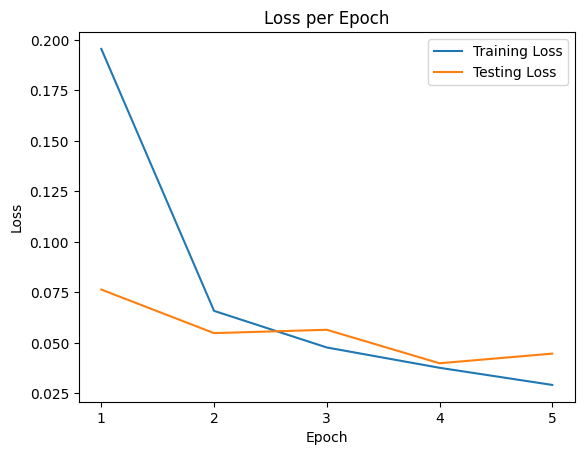

In [ ]:
# Loss per Epoch
train_losses = [x for x in train_losses]
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Testing Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(epoch), range(1, epoch+1))
plt.legend()
plt.show()

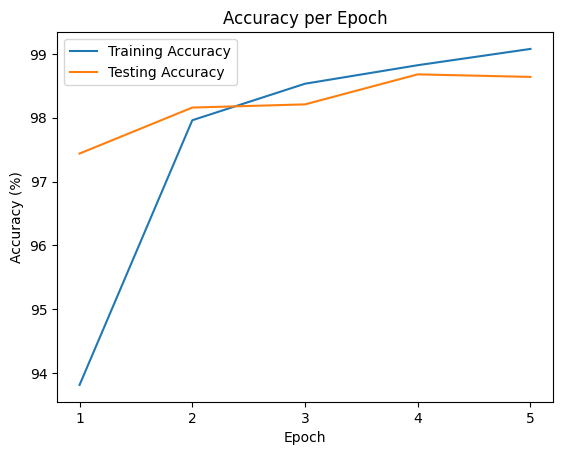

In [ ]:
# Accuracy per Epoch
plt.plot([t/600 for t in train_correct], label='Training Accuracy')
plt.plot([t/100 for t in test_correct], label='Testing Accuracy')
plt.xticks(range(epoch), range(1, epoch+1))
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

## Model Evaluation

In [32]:
with torch.no_grad():
    correct_values = 0
    for i, j in testing_loader:
        y_val = cnn_model_1(i)
        predicted_values = torch.max(y_val,1)[1]
        correct_values += (predicted_values == j).sum()

In [33]:
correct_values.item()/len(testing_data)*100

98.64

## Passing Sample Image through the model

In [ ]:
# Passing one image from the testing_data
with torch.no_grad():
    sample_prediction = cnn_model_1.forward(testing_data[1345][0].reshape(1,1,28,28))

In [ ]:
sample_prediction

tensor([[-2.2339e+01, -1.0092e+01, -4.6610e-05, -1.5824e+01, -2.2076e+01,
         -3.1310e+01, -2.3041e+01, -1.2189e+01, -2.6605e+01, -2.9241e+01]])

In [ ]:
# Viewing the argmax of sample_prediction
sample_prediction.argmax()

tensor(2)

In [34]:
testing_data[1345]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

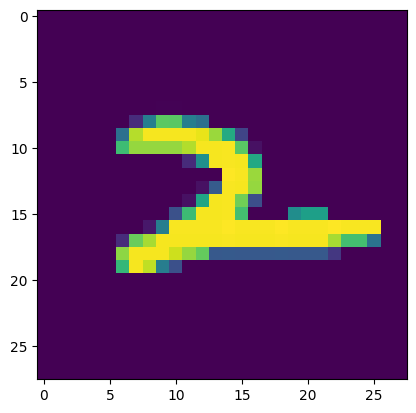

In [35]:
plt.imshow(testing_data[1345][0].reshape(28,28))